# KGD Toughness-Dominated Verification

Verifies the GEOS propagation model against the analytical toughness-dominated
(K-vertex) KGD solution, using the single-fracture base case and the injection-rate
sweep ($Q_0 \ldots Q_0/16$) as an effective resolution study: the ratio of fracture
length to cell size varies by a factor of five across the sweep.

**Analytical solution.** For a plane-strain (KGD) fracture in the toughness-dominated
regime (uniform pressure, no leak-off), propagation at $K_I = K_{Ic}$ with the Sneddon
opening profile and volume balance gives
$$\ell(t) = \left[ \frac{E' Q_0 t}{2\sqrt{\pi} K_{Ic}} \right]^{2/3},$$
equivalent to the standard K-vertex solution $\ell = 0.9324\,(E' Q_0 t / K')^{2/3}$
with $K' = 4\sqrt{2/\pi}K_{Ic}$.

**Convention.** The decks inject $Q_\mathrm{deck}$ into one wing growing from the $y=0$
roller (symmetry) boundary, so the equivalent full bi-wing crack carries
$Q_0 = 2\,Q_\mathrm{deck}/\rho$ per meter of height and the simulated length corresponds
to the analytical half-length $\ell(t)$.

In [4]:
import numpy as np, h5py
import matplotlib.pyplot as plt

HFM = "../outputs/kgd_injection"    # packaged injection-sweep outputs (relative to notebooks/)
GOUT = "../outputs/kgd_spacing"     # packaged spacing-sweep outputs (relative to notebooks/)

Q_0 = 5e-2  # kg/s
runs = {  # label: (timeHistory file, deck mass rate kg/s)
    "$Q_0$ (base, 100 s)": (f"{GOUT}/kgdToughnessDominated_benchmark_2_const_grid_single_rerun/heterogeneousInSitu_timeHistory.hdf5", Q_0),
    "$Q_0$":    (f"{HFM}/kgdToughnessDominated_benchmark_spacing_single_inj_reg_150t/heterogeneousInSitu_timeHistory.hdf5", Q_0),
    "$Q_0/2$":  (f"{HFM}/kgdToughnessDominated_benchmark_spacing_single_inj_half_150t/heterogeneousInSitu_timeHistory.hdf5", Q_0/2),
    "$Q_0/4$":  (f"{HFM}/kgdToughnessDominated_benchmark_spacing_single_inj_qurt_150t/heterogeneousInSitu_timeHistory.hdf5", Q_0/4),
    "$Q_0/8$":  (f"{HFM}/kgdToughnessDominated_benchmark_spacing_single_inj_eighth_150t/heterogeneousInSitu_timeHistory.hdf5", Q_0/8),
    "$Q_0/16$": (f"{HFM}/kgdToughnessDominated_benchmark_spacing_single_inj_sixtineth_150t/heterogeneousInSitu_timeHistory.hdf5", Q_0/16),
}
E, nu, KIc, rho = 30e9, 0.25, 1e6, 1000.0
Ep = E/(1-nu**2)
DY = 0.5   # cell size along propagation direction

In [5]:
import os
SAVEDIR = "../figures/"   # created on demand (relative to notebooks/)
os.makedirs(SAVEDIR, exist_ok=True)

In [6]:
def sim_length(path):
    """Fracture extent along y from the aperture time history (open elements only)."""
    with h5py.File(path, 'r') as f:
        ap = f['elementAperture'][...]
        ec = f['elementAperture elementCenter'][...]
        tt = f['elementAperture Time'][...].ravel()
    L = []
    for i in range(ap.shape[0]):
        n = min(ap.shape[1], ec.shape[1])
        m = ap[i, :n] > 1e-9
        L.append(ec[i, :n, 1][m].max() + DY/2 if m.any() else 0.0)
    return tt, np.array(L)

def ana_length(t, mass_rate):
    Q0 = 2*mass_rate/rho   # full-crack rate per meter of height
    return (Ep*Q0*t/(2*np.sqrt(np.pi)*KIc))**(2.0/3.0)

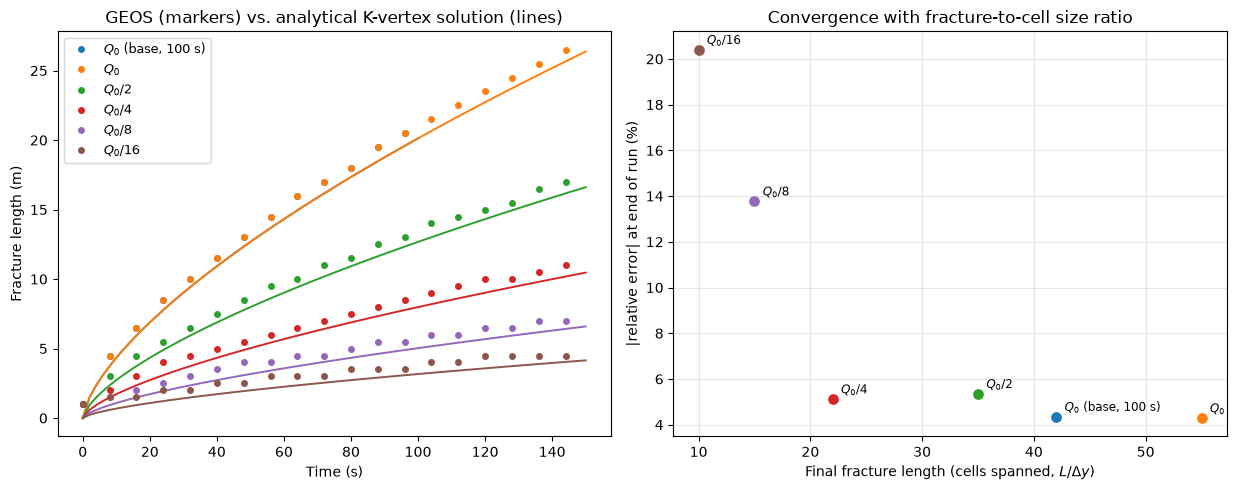

case                     L_sim   L_ana     err  cells
$Q_0$ (base, 100 s)      21.00   20.12   +4.4%     42
$Q_0$                    27.50   26.37   +4.3%     55
$Q_0/2$                  17.50   16.61   +5.3%     35
$Q_0/4$                  11.00   10.46   +5.1%     22
$Q_0/8$                   7.50    6.59  +13.8%     15
$Q_0/16$                  5.00    4.15  +20.4%     10


In [7]:
cmap = plt.get_cmap("tab10")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

rows = []
for k, (name, (path, mr)) in enumerate(runs.items()):
    t, L = sim_length(path)
    ell = ana_length(t, mr)
    c = cmap(k)
    ax1.plot(t, ell, '-', color=c, lw=1.4)
    ax1.plot(t[::4], L[::4], 'o', color=c, ms=4, label=name)
    err = 100*(L[-1] - ell[-1])/ell[-1]
    rows.append((name, L[-1], ell[-1], err, L[-1]/DY))
    ax2.scatter(L[-1]/DY, abs(err), color=c, s=45, zorder=3)
    ax2.annotate(name, (L[-1]/DY, abs(err)), textcoords="offset points",
                 xytext=(6, 4), fontsize=8.5)

ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Fracture length (m)")
ax1.set_title("GEOS (markers) vs. analytical K-vertex solution (lines)")
ax1.legend(fontsize=9)
ax2.set_xlabel("Final fracture length (cells spanned, $L/\\Delta y$)")
ax2.set_ylabel("|relative error| at end of run (%)")
ax2.set_title("Convergence with fracture-to-cell size ratio")
ax2.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(SAVEDIR + "kgd_verification.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"{'case':22s} {'L_sim':>7s} {'L_ana':>7s} {'err':>7s} {'cells':>6s}")
for name, Ls, La, err, cells_ in rows:
    print(f"{name:22s} {Ls:7.2f} {La:7.2f} {err:+6.1f}% {cells_:6.0f}")

The simulated lengths track the analytical solution within about $5\%$ whenever the
fracture spans roughly $20$ cells or more, with the residual error dominated by the
half-cell quantization of the discrete front position.  At the lowest rates the fracture
spans only $10$--$15$ cells and the quantization error grows accordingly.  The figure is
used in the thesis (Chapter 2, convergence and verification checks).